In [5]:
import numpy as np  # used in build_skel_compartments_from_mesh_annos
import caveclient
import pcg_skel
import skeleton_plot as skelplot
import matplotlib.pyplot as plt

# ---- edit these for your run ----
DATASTACK = "wclee_mouse_spinalcord_cltmr"
ROOT_ID1 = 720575940899282056
SOMA1 = [29821, 3649, 1279]
ROOT_ID2 = 720575940883908892
SOMA2 = [24396, 3221, 2237]
ROOT_RESOLUTION = (32, 32, 45)
COLLAPSE_RADIUS = 7500
AXON_QUALITY_THRESH = 0.2
DIST_THRESHOLD_NM = 5000.0
MAX_PAIRS_PER_DIR = 5000
OUT_PATH = "/Users/wangchu/connectivity_analysis/test_close_contacts_artifacts_2.npz"   # saved for visualization script

client = caveclient.CAVEclient(DATASTACK)

In [6]:
def nm_to_px(x_nm, res=ROOT_RESOLUTION):
    x_nm = np.asarray(x_nm, dtype=float)
    return x_nm / np.asarray(res, dtype=float)

def px_to_nm(x_px, res=ROOT_RESOLUTION):
    x_px = np.asarray(x_px, dtype=float)
    return x_px * np.asarray(res, dtype=float)

#%% Mesh→skeleton compartment projection (unchanged)
def build_skel_compartments_from_mesh_annos(
    nrn,
    skel,
    axon_anno="is_axon",
    apical_anno=None,
    basal_anno=None,
    default_non_axon=3,
):
    """
    Project mesh-level annotations to a full per-skeleton-vertex 'compartment' label array.

    Returns: np.ndarray[int] with labels in {2='axon', 3='basal', 4='apical', default_non_axon}.
    Also writes skel.vertex_properties['compartment'].
    """
    def _mesh_bool_from_anno(name):
        if name is None or not hasattr(nrn.anno, name):
            return None
        df = getattr(nrn.anno, name).df  # expects a column 'mesh_index'
        if "mesh_index" not in df.columns:
            col = "mesh_ind" if "mesh_ind" in df.columns else None
            if col is None:
                raise ValueError(f"{name} has no mesh_index/mesh_ind column.")
            idxs = df[col].to_numpy()
        else:
            idxs = df["mesh_index"].to_numpy()
        return set(np.asarray(idxs, dtype=np.int64))

    axon_mesh = _mesh_bool_from_anno(axon_anno)
    apical_mesh = _mesh_bool_from_anno(apical_anno) if apical_anno else None
    basal_mesh = _mesh_bool_from_anno(basal_anno) if basal_anno else None

    if not hasattr(skel, "mesh_index") or skel.mesh_index is None:
        raise ValueError("skel.mesh_index is required to project mesh annotations to skeleton.")
    sk_mi = np.asarray(skel.mesh_index, dtype=np.int64)

    comp = np.full(len(sk_mi), default_non_axon, dtype=int)
    if axon_mesh:
        comp[np.isin(sk_mi, list(axon_mesh))] = 2
    if apical_mesh:
        comp[np.isin(sk_mi, list(apical_mesh))] = 4
    if basal_mesh:
        comp[np.isin(sk_mi, list(basal_mesh))] = 3

    comp = np.where(comp == None, default_non_axon, comp)  # noqa: E711
    skel.vertex_properties["compartment"] = comp
    return comp

#%% Build two neurons & annotate axon (unchanged)
def build_two_neurons_with_is_axon(
    root_id1,
    soma_location1,
    root_id2,
    soma_location2,
    client,
    root_resolution=ROOT_RESOLUTION,
    collapse_radius=COLLAPSE_RADIUS,
    threshold_quality=AXON_QUALITY_THRESH,
):
    """
    Build (skel, nrn) for each neuron and annotate axon via is_axon heuristic.
    Returns: skel1, nrn1, comp1, skel2, nrn2, comp2
    """
    skel1, mesh1, (l2_to_skel1, skel_to_l21) = pcg_skel.pcg_skeleton(
        root_id1,
        client,
        return_mesh=True,
        root_point=soma_location1,
        root_point_resolution=root_resolution,
        collapse_soma=True,
        collapse_radius=collapse_radius,
        return_l2dict=True,
    )

    nrn1 = pcg_skel.pcg_meshwork(
        root_id=root_id1,
        client=client,
        root_point=soma_location1,
        root_point_resolution=root_resolution,
        collapse_soma=True,
        collapse_radius=collapse_radius,
        synapses=True,
    )
    pcg_skel.features.add_synapse_count(nrn1)
    pcg_skel.features.add_is_axon_annotation(
        nrn1,
        pre_anno="pre_syn",
        post_anno="post_syn",
        annotation_name="is_axon",
        return_quality=True,
        threshold_quality=threshold_quality,
    )

    skel2, mesh2, (l2_to_skel2, skel_to_l22) = pcg_skel.pcg_skeleton(
        root_id2,
        client,
        return_mesh=True,
        root_point=soma_location2,
        root_point_resolution=root_resolution,
        collapse_soma=True,
        collapse_radius=collapse_radius,
        return_l2dict=True,
    )

    nrn2 = pcg_skel.pcg_meshwork(
        root_id=root_id2,
        client=client,
        root_point=soma_location2,
        root_point_resolution=root_resolution,
        collapse_soma=True,
        collapse_radius=collapse_radius,
        synapses=True,
    )
    pcg_skel.features.add_synapse_count(nrn2)
    pcg_skel.features.add_is_axon_annotation(
        nrn2,
        pre_anno="pre_syn",
        post_anno="post_syn",
        annotation_name="is_axon",
        return_quality=True,
        threshold_quality=threshold_quality,
    )

    comp1 = build_skel_compartments_from_mesh_annos(nrn1, skel1, axon_anno="is_axon")
    comp2 = build_skel_compartments_from_mesh_annos(nrn2, skel2, axon_anno="is_axon")

    # Temporary color preview (unchanged behavior)
    skel1.vertex_properties = dict(getattr(skel1, "vertex_properties", {}) or {})
    skel1.vertex_properties["compartment"] = comp1
    skelplot.plot_tools.plot_skel(skel1, line_width=1, plot_soma=True, invert_y=True)
    del skel1.vertex_properties["compartment"]

    skel2.vertex_properties = dict(getattr(skel2, "vertex_properties", {}) or {})
    skel2.vertex_properties["compartment"] = comp2
    skelplot.plot_tools.plot_skel(skel2, line_width=1, plot_soma=True, invert_y=True)
    del skel2.vertex_properties["compartment"]

    return skel1, nrn1, comp1, skel2, nrn2, comp2

#%% Pair finding (unchanged core, includes KD-tree + fallback)
from scipy.spatial import cKDTree

def _find_pairs_within_threshold(A_nm, B_nm, thr_nm, use_kdtree=True):
    """
    Return (pairs, dists) where pairs[:,0] are indices in A, pairs[:,1] in B,
    for all pairs within Euclidean distance <= thr_nm. Works in nm space.
    """
    if A_nm.size == 0 or B_nm.size == 0:
        return np.empty((0,2), dtype=int), np.empty((0,), dtype=float)

    if use_kdtree:
        try:
            tree = cKDTree(B_nm)
            neigh = tree.query_ball_point(A_nm, r=thr_nm)
            pairs = []
            dists = []
            for i, js in enumerate(neigh):
                if not js:
                    continue
                a = A_nm[i]
                bsel = B_nm[np.asarray(js, dtype=int)]
                ds = np.linalg.norm(bsel - a, axis=1)
                dists.extend(ds.tolist())
                gi = np.full(len(js), i, dtype=int)
                gj = np.asarray(js, dtype=int)
                pairs.append(np.stack([gi, gj], axis=1))
            if pairs:
                pairs = np.concatenate(pairs, axis=0)
                dists = np.asarray(dists, dtype=float)
            else:
                pairs = np.empty((0,2), dtype=int)
                dists = np.empty((0,), dtype=float)
            return pairs, dists
        except Exception:
            pass

    # NumPy fallback
    thr2 = float(thr_nm) ** 2
    A2 = np.sum(A_nm*A_nm, axis=1, keepdims=True)
    B2 = np.sum(B_nm*B_nm, axis=1, keepdims=True).T
    AB = A_nm @ B_nm.T
    dist2 = A2 + B2 - 2.0 * AB
    np.maximum(dist2, 0.0, out=dist2)
    ai, bj = np.where(dist2 <= thr2)
    if ai.size == 0:
        return np.empty((0,2), dtype=int), np.empty((0,), dtype=float)
    pairs = np.stack([ai, bj], axis=1)
    dists = np.sqrt(dist2[ai, bj], dtype=float)
    return pairs, dists

#%% Compute close axon↔dend pairs + build meta (unchanged logic)
def compute_close_pairs_and_meta(
    root_id1, verts1_nm, comp1,
    root_id2, verts2_nm, comp2,
    threshold_nm=DIST_THRESHOLD_NM,
    root_resolution=ROOT_RESOLUTION,
    max_pairs_per_dir=MAX_PAIRS_PER_DIR,
    dendrite_labels=(3, 4),
):
    axon_label = 2
    verts1_nm = np.asarray(verts1_nm, dtype=float)
    verts2_nm = np.asarray(verts2_nm, dtype=float)
    comp1 = np.asarray(comp1)
    comp2 = np.asarray(comp2)

    mask1_ax = (comp1 == axon_label)
    mask1_dn = np.isin(comp1, dendrite_labels)
    mask2_ax = (comp2 == axon_label)
    mask2_dn = np.isin(comp2, dendrite_labels)

    v1_ax_nm = verts1_nm[mask1_ax]
    v1_dn_nm = verts1_nm[mask1_dn]
    v2_ax_nm = verts2_nm[mask2_ax]
    v2_dn_nm = verts2_nm[mask2_dn]

    pairs_1ax_2dn, dists_12 = _find_pairs_within_threshold(v1_ax_nm, v2_dn_nm, threshold_nm)
    pairs_2ax_1dn, dists_21 = _find_pairs_within_threshold(v2_ax_nm, v1_dn_nm, threshold_nm)

    def _cap_pairs(pairs, dists):
        if pairs.shape[0] <= max_pairs_per_dir:
            return pairs, dists
        idx = np.linspace(0, pairs.shape[0]-1, max_pairs_per_dir, dtype=int)
        return pairs[idx], (dists[idx] if dists is not None and dists.size else dists)

    pairs_1ax_2dn, dists_12 = _cap_pairs(pairs_1ax_2dn, dists_12)
    pairs_2ax_1dn, dists_21 = _cap_pairs(pairs_2ax_1dn, dists_21)

    idx1_all = np.arange(verts1_nm.shape[0])
    idx2_all = np.arange(verts2_nm.shape[0])
    idx1_ax = idx1_all[mask1_ax]
    idx1_dn = idx1_all[mask1_dn]
    idx2_ax = idx2_all[mask2_ax]
    idx2_dn = idx2_all[mask2_dn]

    global_pairs_12 = np.column_stack([idx1_ax[pairs_1ax_2dn[:,0]],
                                       idx2_dn[pairs_1ax_2dn[:,1]]]).astype(int)
    global_pairs_21 = np.column_stack([idx2_ax[pairs_2ax_1dn[:,0]],
                                       idx1_dn[pairs_2ax_1dn[:,1]]]).astype(int)

    meta = {
        "n_pairs_1axon_2dend": int(global_pairs_12.shape[0]),
        "n_pairs_2axon_1dend": int(global_pairs_21.shape[0]),
        "threshold_nm": float(threshold_nm),
        "resolution_nm_per_pixel": tuple(float(x) for x in root_resolution),
        # arrays below saved explicitly in .npz
    }
    return meta, global_pairs_12, global_pairs_21, dists_12, dists_21

[saved] /Users/wangchu/connectivity_analysis/test_close_contacts_artifacts_2.npz


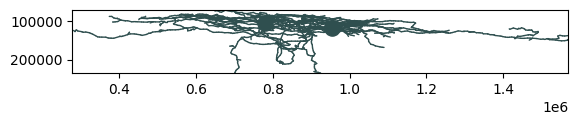

In [7]:
if __name__ == "__main__":
    skel1, nrn1, comp1, skel2, nrn2, comp2 = build_two_neurons_with_is_axon(
        ROOT_ID1, SOMA1, ROOT_ID2, SOMA2, client,
        root_resolution=ROOT_RESOLUTION,
        collapse_radius=COLLAPSE_RADIUS,
        threshold_quality=AXON_QUALITY_THRESH,
    )

    meta, gp12, gp21, d12, d21 = compute_close_pairs_and_meta(
        ROOT_ID1, skel1.vertices, comp1,
        ROOT_ID2, skel2.vertices, comp2,
        threshold_nm=DIST_THRESHOLD_NM,
        root_resolution=ROOT_RESOLUTION,
        max_pairs_per_dir=MAX_PAIRS_PER_DIR
    )

    # Save minimal bridge so the viz script doesn't recompute heavy steps
    # (vertices + edges + global pairs + dists + scalar meta)
    np.savez(
        OUT_PATH,
        root_id1=np.array([ROOT_ID1], dtype=np.int64),
        root_id2=np.array([ROOT_ID2], dtype=np.int64),
        root_resolution=np.array(ROOT_RESOLUTION, dtype=float),
        skel1_vertices=skel1.vertices,
        skel2_vertices=skel2.vertices,
        skel1_edges=skel1.edges,
        skel2_edges=skel2.edges,
        global_pairs_1axon_2dend=gp12,
        global_pairs_2axon_1dend=gp21,
        dists_1axon_2dend_nm=d12,
        dists_2axon_1dend_nm=d21,
        n_pairs_1axon_2dend=np.array([meta["n_pairs_1axon_2dend"]], dtype=int),
        n_pairs_2axon_1dend=np.array([meta["n_pairs_2axon_1dend"]], dtype=int),
        threshold_nm=np.array([meta["threshold_nm"]], dtype=float),
    )
    print(f"[saved] {OUT_PATH}")

In [8]:
# Libraries
import caveclient
import subprocess
import json
import numpy as np
import matplotlib.pyplot as plt

import cloudvolume
from tqdm import tqdm
import glob
import os
import json
# Setup caveclient
client = caveclient.CAVEclient("wclee_mouse_spinalcord_cltmr", ) #server_address='https://global.daf-apis.com')

In [11]:
# Synapses df
in_df = client.materialize.query_table('excitatory_neuron_label')
exn_df = client.materialize.query_table('spinalcord_neuron_clusters')

In [12]:
set(in_df['tag'])

{'IN for abltmr',
 'IN for adhtmr',
 'IN for vertical cell',
 'c1',
 'c1, pep',
 'c2',
 'c3',
 'c4',
 'islet-adltmr',
 'islet-chtmr',
 'islet-cltmr',
 'p',
 'r',
 'u',
 'v_auto',
 'v_manual'}

In [13]:
import pandas as pd
import numpy as np

ALLOWED_TAGS = {
    "IN for abltmr",
    "IN for adhtmr",
    "IN for vertical cell",
}

def coord_to_str(xyz):
    """Coerce a 3-vector into 'x,y,z' string of ints."""
    arr = np.asarray(xyz).astype(float).ravel()
    if arr.size != 3:
        raise ValueError(f"Coordinate must have 3 elements, got {arr}")
    arr = arr.astype(int)
    return f"{arr[0]},{arr[1]},{arr[2]}"

def normalize_pt_position_col(col):
    """Map list/tuple/array or strings like '[x y z]' or 'x,y,z' → 'x,y,z'."""
    out = []
    for v in col:
        if isinstance(v, str):
            s = v.strip().replace("[", "").replace("]", "").replace("(", "").replace(")", "")
            parts = [p for p in s.replace(",", " ").split() if p]
            if len(parts) != 3:
                raise ValueError(f"Could not parse pt_position: {v}")
            arr = np.array(parts, dtype=float)
            out.append(coord_to_str(arr))
        else:
            out.append(coord_to_str(v))
    return out

# ---- Posts (from exn_df) ----
posts = exn_df.loc[:, ["pt_root_id", "pt_position"]].copy()
posts.rename(columns={"pt_root_id": "post_id"}, inplace=True)
posts["post_coord"] = normalize_pt_position_col(posts["pt_position"])
posts = posts.drop(columns=["pt_position"]).drop_duplicates()
posts["__key__"] = 1  # for cross join

# ---- Pres (from in_df, filtered by tag) ----
pres = in_df.loc[:, ["pt_root_id", "pt_position", "tag"]].copy()
pres = pres[pres["tag"].isin(ALLOWED_TAGS)].copy()
pres.rename(columns={"pt_root_id": "pre_id"}, inplace=True)
pres["pre_coord"] = normalize_pt_position_col(pres["pt_position"])
pres = pres.drop(columns=["pt_position"]).drop_duplicates(subset=["pre_id","pre_coord","tag"])
pres["__key__"] = 1  # for cross join

# ---- Cross join: every pre × every post ----
pairs_df = posts.merge(pres, on="__key__").drop(columns="__key__")

# Final column order (no pre_axon_coord)
pairs_df = pairs_df[["post_id", "post_coord", "pre_id", "pre_coord", "tag"]]

print(f"[summary] posts: {posts.shape[0]} | pres (filtered): {pres.shape[0]} | pairs: {pairs_df.shape[0]}")
pairs_df.head(3)

# Optional: save (pandas will quote 'x,y,z' coords correctly)
# pairs_df.to_csv("pairs_IN_to_posts_no_pre_axon_coord.csv", index=False)


[summary] posts: 223 | pres (filtered): 21 | pairs: 4683


,post_id,post_coord,pre_id,pre_coord,tag
0,720575940865160474,"22364,2792,812",720575940884147711,"37934,6202,141",IN for adhtmr
1,720575940865160474,"22364,2792,812",720575940878345851,"27837,3887,654",IN for adhtmr
2,720575940865160474,"22364,2792,812",720575940925834822,"17933,2855,2476",IN for adhtmr


In [14]:
# ==== RUN THIS CELL ====
import os, gc, csv, time
import numpy as np
import pandas as pd
import caveclient
from collections import deque, defaultdict
from heapq import heappush, heappop
from scipy.spatial import cKDTree

# =========================
# Config (edit if needed)
# =========================
DATASTACK         = "wclee_mouse_spinalcord_cltmr"
ROOT_RESOLUTION   = (32, 32, 45)  # nm/px
COLLAPSE_RADIUS   = 7500          # nm
AXON_QUALITY_THRESH = 0.2
DIST_THRESHOLD_NM = 5000.0
MAX_PAIRS_PER_DIR = 200_000
HOP_TOL_A = 1   # axon-side hop tolerance for clustering
HOP_TOL_B = 1   # dendrite-side hop tolerance for clustering
PROGRESS_EVERY = 25  # print progress every N rows

# =========================
# Helpers: coords & strings
# =========================
def _parse_coord_any(x):
    """Accept [x,y,z], (x,y,z), np.array, or 'x,y,z'/'[x y z]' strings. Return int np.array(3,)."""
    if isinstance(x, (list, tuple, np.ndarray)):
        arr = np.asarray(x, dtype=float).ravel()
    elif isinstance(x, str):
        s = x.strip().replace("[", "").replace("]", "").replace("(", "").replace(")", "")
        parts = [p for p in s.replace(",", " ").split() if p]
        if len(parts) != 3:
            raise ValueError(f"Bad coord string: {x}")
        arr = np.array(parts, dtype=float)
    else:
        raise TypeError(f"Unsupported coord type: {type(x)}")
    if arr.size != 3:
        raise ValueError(f"Coordinate must have 3 elements, got {arr}")
    return arr.astype(int)

def _coord_key(xyz):
    a = _parse_coord_any(xyz)
    return f"{int(a[0])},{int(a[1])},{int(a[2])}"

def _fmt_hms(seconds):
    seconds = int(seconds)
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60
    return f"{h:d}:{m:02d}:{s:02d}"

# =========================
# Mesh→skel compartment projection
# =========================
def build_skel_compartments_from_mesh_annos(
    nrn, skel, axon_anno="is_axon", apical_anno=None, basal_anno=None, default_non_axon=3
):
    def _mesh_bool_from_anno(name):
        if name is None or not hasattr(nrn.anno, name):
            return None
        df = getattr(nrn.anno, name).df
        if "mesh_index" not in df.columns:
            col = "mesh_ind" if "mesh_ind" in df.columns else None
            if col is None:
                raise ValueError(f"{name} has no mesh_index/mesh_ind column.")
            idxs = df[col].to_numpy()
        else:
            idxs = df["mesh_index"].to_numpy()
        return set(np.asarray(idxs, dtype=np.int64))

    axon_mesh  = _mesh_bool_from_anno(axon_anno)
    apical_mesh = _mesh_bool_from_anno(apical_anno) if apical_anno else None
    basal_mesh  = _mesh_bool_from_anno(basal_anno)  if basal_anno  else None

    if not hasattr(skel, "mesh_index") or skel.mesh_index is None:
        raise ValueError("skel.mesh_index is required to project mesh annotations to skeleton.")
    sk_mi = np.asarray(skel.mesh_index, dtype=np.int64)

    comp = np.full(len(sk_mi), default_non_axon, dtype=int)
    if axon_mesh:
        comp[np.isin(sk_mi, list(axon_mesh))] = 2
    if apical_mesh:
        comp[np.isin(sk_mi, list(apical_mesh))] = 4
    if basal_mesh:
        comp[np.isin(sk_mi, list(basal_mesh))] = 3
    comp = np.where(comp == None, default_non_axon, comp)  # noqa: E711
    return comp

# =========================
# Build arrays for post (dendrites) and pre (axons)
# =========================
def build_post_arrays(
    root_id, soma_px, client, root_resolution=ROOT_RESOLUTION,
    collapse_radius=COLLAPSE_RADIUS, threshold_quality=AXON_QUALITY_THRESH
):
    import pcg_skel
    skel, _, _ = pcg_skel.pcg_skeleton(
        int(root_id), client,
        return_mesh=True,
        root_point=_parse_coord_any(soma_px).tolist(),
        root_point_resolution=root_resolution,
        collapse_soma=True, collapse_radius=collapse_radius,
        return_l2dict=True,
    )
    verts = np.asarray(skel.vertices, float)
    edges = np.asarray(skel.edges, int)

    nrn = pcg_skel.pcg_meshwork(
        root_id=int(root_id), client=client,
        root_point=_parse_coord_any(soma_px).tolist(),
        root_point_resolution=root_resolution,
        collapse_soma=True, collapse_radius=collapse_radius,
        synapses=True,
    )
    pcg_skel.features.add_synapse_count(nrn)
    pcg_skel.features.add_is_axon_annotation(
        nrn, pre_anno="pre_syn", post_anno="post_syn",
        annotation_name="is_axon", return_quality=True, threshold_quality=threshold_quality,
    )
    comp = build_skel_compartments_from_mesh_annos(nrn, skel, axon_anno="is_axon")

    del skel, nrn
    gc.collect()

    mask_dn = np.isin(np.asarray(comp), (3, 4))  # dendrite labels
    return verts, edges, mask_dn

def build_pre_arrays(
    root_id, soma_px, client, root_resolution=ROOT_RESOLUTION,
    collapse_radius=COLLAPSE_RADIUS, threshold_quality=AXON_QUALITY_THRESH
):
    import pcg_skel
    skel, _, _ = pcg_skel.pcg_skeleton(
        int(root_id), client,
        return_mesh=True,
        root_point=_parse_coord_any(soma_px).tolist(),
        root_point_resolution=root_resolution,
        collapse_soma=True, collapse_radius=collapse_radius,
        return_l2dict=True,
    )
    verts = np.asarray(skel.vertices, float)
    edges = np.asarray(skel.edges, int)

    nrn = pcg_skel.pcg_meshwork(
        root_id=int(root_id), client=client,
        root_point=_parse_coord_any(soma_px).tolist(),
        root_point_resolution=root_resolution,
        collapse_soma=True, collapse_radius=collapse_radius,
        synapses=True,
    )
    pcg_skel.features.add_synapse_count(nrn)
    pcg_skel.features.add_is_axon_annotation(
        nrn, pre_anno="pre_syn", post_anno="post_syn",
        annotation_name="is_axon", return_quality=True, threshold_quality=threshold_quality,
    )
    comp = build_skel_compartments_from_mesh_annos(nrn, skel, axon_anno="is_axon")

    del skel, nrn
    gc.collect()

    mask_ax = (np.asarray(comp) == 2)  # axon label
    return verts, edges, mask_ax

# =========================
# Pair finding + clustering
# =========================
def _find_pairs_within_threshold(A_nm, B_nm, thr_nm):
    if A_nm.size == 0 or B_nm.size == 0:
        return np.empty((0, 2), int), np.empty((0,), float)
    try:
        tree = cKDTree(B_nm)
        neigh = tree.query_ball_point(A_nm, r=thr_nm)
        pairs, dists = [], []
        for i, js in enumerate(neigh):
            if not js: continue
            a = A_nm[i]; bsel = B_nm[np.asarray(js, int)]
            ds = np.linalg.norm(bsel - a, axis=1)
            dists.extend(ds.tolist())
            gi = np.full(len(js), i, int); gj = np.asarray(js, int)
            pairs.append(np.stack([gi, gj], axis=1))
        if pairs:
            pairs = np.concatenate(pairs, axis=0)
            dists = np.asarray(dists, float)
        else:
            pairs = np.empty((0, 2), int); dists = np.empty((0,), float)
        return pairs, dists
    except Exception:
        pass
    thr2 = float(thr_nm) ** 2
    A2 = np.sum(A_nm * A_nm, axis=1, keepdims=True)
    B2 = np.sum(B_nm * B_nm, axis=1, keepdims=True).T
    AB = A_nm @ B_nm.T
    dist2 = A2 + B2 - 2.0 * AB
    np.maximum(dist2, 0.0, out=dist2)
    ai, bj = np.where(dist2 <= thr2)
    if ai.size == 0:
        return np.empty((0, 2), int), np.empty((0,), float)
    pairs = np.stack([ai, bj], axis=1)
    dists = np.sqrt(dist2[ai, bj], dtype=float)
    return pairs, dists

def build_adj_from_edges(edges):
    adj = defaultdict(list)
    for u, v in np.asarray(edges, dtype=int):
        adj[u].append(v); adj[v].append(u)
    return adj

def k_hop_neighborhoods(adj, seeds, k=1):
    seeds = list(map(int, set(seeds)))
    out = {s: set([s]) for s in seeds}
    for s in seeds:
        if k <= 0: continue
        seen = {s}; q = deque([(s, 0)])
        while q:
            u, d = q.popleft()
            if d == k: continue
            for w in adj.get(u, []):
                if w not in seen:
                    seen.add(w); out[s].add(w); q.append((w, d + 1))
    return out

def induced_geodesic_diameter(adj, coords_nm, nodes_subset):
    nodes = list(set(map(int, nodes_subset)))
    if len(nodes) == 0:
        return 0.0, (None, None)
    allowed = set(nodes)
    def elen(u, v): return float(np.linalg.norm(coords_nm[u] - coords_nm[v]))
    deg_in = {u: 0 for u in nodes}
    internal_len = 0.0; seen_pairs = set()
    for u in nodes:
        for v in adj.get(u, []):
            if v in allowed:
                if u < v and (u, v) not in seen_pairs:
                    internal_len += elen(u, v); seen_pairs.add((u, v))
                deg_in[u] += 1
    endpoints = [u for u in nodes if deg_in[u] == 1]
    half_ext_total = 0.0
    if len(nodes) == 1:
        u = nodes[0]
        outs = [elen(u, v) for v in adj.get(u, []) if v not in allowed]
        outs.sort()
        if len(outs) >= 2: half_ext_total += 0.5 * (outs[0] + outs[1])
        elif len(outs) == 1: half_ext_total += 0.5 * outs[0]
    else:
        for u in endpoints:
            outs = [elen(u, v) for v in adj.get(u, []) if v not in allowed]
            if outs: half_ext_total += 0.5 * min(outs)
    adjusted_len = float(internal_len + half_ext_total)
    if len(endpoints) == 2:
        return adjusted_len, (int(endpoints[0]), int(endpoints[1]))

    def dijkstra_subset_weighted(adj, coords_nm, start, allowed):
        allowed = set(allowed)
        if start not in allowed: return {}
        dist = {start: 0.0}; pq = [(0.0, start)]
        while pq:
            du, u = heappop(pq)
            if du > dist[u]: continue
            for v in adj.get(u, []):
                if v not in allowed: continue
                w = float(np.linalg.norm(coords_nm[u] - coords_nm[v]))
                alt = du + w
                if v not in dist or alt < dist[v]:
                    dist[v] = alt; heappush(pq, (alt, v))
        return dist
    best_len = -1.0; best_pair = (nodes[0], nodes[0])
    for s in nodes:
        dist = dijkstra_subset_weighted(adj, coords_nm, s, allowed)
        if not dist: continue
        v = max(dist, key=dist.get)
        if dist[v] > best_len:
            best_len = dist[v]; best_pair = (s, v)
    return adjusted_len, (int(best_pair[0]), int(best_pair[1]))

def cluster_pairs_by_skeleton_connectivity(pairs, edgesA, edgesB, coordsA_nm, coordsB_nm, hop_tol_A=1, hop_tol_B=1):
    pairs = np.asarray(pairs, dtype=int)
    if pairs.size == 0: return []
    adjA = build_adj_from_edges(edgesA); adjB = build_adj_from_edges(edgesB)
    A_verts = pairs[:, 0]; B_verts = pairs[:, 1]
    A_khop = k_hop_neighborhoods(adjA, A_verts, k=hop_tol_A)
    B_khop = k_hop_neighborhoods(adjB, B_verts, k=hop_tol_B)
    M = pairs.shape[0]; pair_adj = [[] for _ in range(M)]
    for i in range(M):
        a_i, b_i = int(pairs[i, 0]), int(pairs[i, 1])
        A_near = A_khop.get(a_i, {a_i}); B_near = B_khop.get(b_i, {b_i})
        for j in range(i + 1, M):
            a_j, b_j = int(pairs[j, 0]), int(pairs[j, 1])
            if (a_j in A_near) and (b_j in B_near):
                pair_adj[i].append(j); pair_adj[j].append(i)
    seen = np.zeros(M, dtype=bool); comps = []
    for i in range(M):
        if seen[i]: continue
        stack = [i]; seen[i] = True; comp = [i]
        while stack:
            u = stack.pop()
            for v in pair_adj[u]:
                if not seen[v]:
                    seen[v] = True; stack.append(v); comp.append(v)
        comps.append(np.array(comp, dtype=int))
    regions = []
    for rows in comps:
        A_nodes = np.unique(pairs[rows, 0]); B_nodes = np.unique(pairs[rows, 1])
        A_diam_nm, _ = induced_geodesic_diameter(adjA, coordsA_nm, A_nodes)
        B_diam_nm, _ = induced_geodesic_diameter(adjB, coordsB_nm, B_nodes)
        regions.append({
            "A_vertices": A_nodes, "B_vertices": B_nodes,
            "A_diameter_nm": float(A_diam_nm), "B_diameter_nm": float(B_diam_nm),
            "overlap_distance_nm": float(min(A_diam_nm, B_diam_nm)),
        })
    regions.sort(key=lambda r: r["overlap_distance_nm"], reverse=True)
    return regions

def axon_length_nm_from_regions(regions, edgesA, coordsA_nm):
    if not regions: return 0.0
    A_union = np.unique(np.concatenate([r["A_vertices"] for r in regions if len(r["A_vertices"])])) if regions else np.array([], int)
    if A_union.size == 0: return 0.0
    adjA = build_adj_from_edges(edgesA)
    length_nm, _ = induced_geodesic_diameter(adjA, coordsA_nm, A_union)
    return float(length_nm)

# =========================
# Core per-pair computation using masks (pre axon → post dendrite)
# =========================
def overlap_preAx_to_postDn_from_arrays(
    verts_post, edges_post, mask_post_dn,
    verts_pre,  edges_pre,  mask_pre_ax,
    dist_threshold_nm=DIST_THRESHOLD_NM,
    max_pairs=MAX_PAIRS_PER_DIR,
    hop_tol_A=HOP_TOL_A, hop_tol_B=HOP_TOL_B
):
    v_post_dn = verts_post[mask_post_dn]
    v_pre_ax  = verts_pre [mask_pre_ax]
    if v_post_dn.size == 0 or v_pre_ax.size == 0:
        return 0.0

    # find pairs: A = pre axon, B = post dendrite
    pairs_local, _ = _find_pairs_within_threshold(v_pre_ax, v_post_dn, dist_threshold_nm)
    if pairs_local.shape[0] == 0:
        return 0.0
    if pairs_local.shape[0] > max_pairs:
        keep = np.linspace(0, pairs_local.shape[0]-1, max_pairs, dtype=int)
        pairs_local = pairs_local[keep]

    # map local to global indices
    idx_post_all = np.arange(verts_post.shape[0])
    idx_pre_all  = np.arange(verts_pre.shape[0])
    idx_post_dn  = idx_post_all[mask_post_dn]
    idx_pre_ax   = idx_pre_all [mask_pre_ax]
    global_pairs = np.column_stack([idx_pre_ax[pairs_local[:,0]], idx_post_dn[pairs_local[:,1]]]).astype(int)

    # cluster & compute axon length participating (on pre side)
    regions = cluster_pairs_by_skeleton_connectivity(
        global_pairs, edgesA=edges_pre, edgesB=edges_post,
        coordsA_nm=verts_pre, coordsB_nm=verts_post,
        hop_tol_A=hop_tol_A, hop_tol_B=hop_tol_B
    )
    length_nm = axon_length_nm_from_regions(regions, edgesA=edges_pre, coordsA_nm=verts_pre)
    return float(length_nm)

# =========================
# Batch runner (resume-able) + progress printing
# =========================
def compute_preAx_postDn_overlaps(
    pairs_df,
    out_csv="overlap_preAx_postDn.csv",
    datastack=DATASTACK,
    root_resolution=ROOT_RESOLUTION,
    collapse_radius_nm=COLLAPSE_RADIUS,
    axon_quality_thresh=AXON_QUALITY_THRESH,
    dist_threshold_nm=DIST_THRESHOLD_NM,
    max_pairs=MAX_PAIRS_PER_DIR,
    hop_tol_A=HOP_TOL_A, hop_tol_B=HOP_TOL_B,
    resume=True,
    cache_pres=True,
    progress_every=PROGRESS_EVERY,
):
    """
    pairs_df columns required: post_id, post_coord, pre_id, pre_coord. (Optional: tag)
    Writes CSV with: post_id,post_coord,pre_id,pre_coord[,tag],overlap (µm).
    """
    client = caveclient.CAVEclient(datastack)

    # Validate columns
    df = pairs_df.copy()
    required = {"post_id", "post_coord", "pre_id", "pre_coord"}
    if not required.issubset(df.columns):
        raise ValueError(f"pairs_df missing columns: {required - set(df.columns)}")

    # Normalize coord strings (consistent keys)
    df["post_coord_norm"] = df["post_coord"].map(_coord_key)
    df["pre_coord_norm"]  = df["pre_coord"].map(_coord_key)

    # Resume support
    processed = set()
    header_needed = True
    keep_tag = "tag" in df.columns
    out_cols = ["post_id","post_coord","pre_id","pre_coord","overlap"] if not keep_tag \
               else ["post_id","post_coord","pre_id","pre_coord","tag","overlap"]

    if resume and os.path.exists(out_csv):
        try:
            done = pd.read_csv(out_csv, dtype={"post_id": np.int64, "pre_id": np.int64})
            if {"post_coord","pre_coord"}.issubset(done.columns):
                done["post_coord_norm"] = done["post_coord"].map(_coord_key)
                done["pre_coord_norm"]  = done["pre_coord"].map(_coord_key)
                for _, r in done.iterrows():
                    processed.add((int(r["post_id"]), r["post_coord_norm"], int(r["pre_id"]), r["pre_coord_norm"]))
            header_needed = False
            print(f"[resume] found {len(processed)} completed rows in {out_csv}")
        except Exception as e:
            print(f"[resume warning] Could not read {out_csv}: {e}. Will (re)create file.")
            header_needed = True

    # Optionally cache unique pres (can be many; set cache_pres=False if RAM is tight)
    pre_cache = {}
    if cache_pres:
        uniq_pres = df[["pre_id","pre_coord_norm"]].drop_duplicates()
        print(f"[cache] pre-building {len(uniq_pres)} pre neurons…")
        for _, row in uniq_pres.iterrows():
            rid = int(row["pre_id"])
            soma = _parse_coord_any(row["pre_coord_norm"])
            vp, ep, mask_ax = build_pre_arrays(
                rid, soma, client,
                root_resolution=root_resolution,
                collapse_radius=collapse_radius_nm,
                threshold_quality=axon_quality_thresh,
            )
            pre_cache[(rid, row["pre_coord_norm"])] = (vp, ep, mask_ax)

    # CSV writer (quote coords)
    out_fh = open(out_csv, "a" if not header_needed else "w", newline="")
    writer = csv.writer(out_fh, quoting=csv.QUOTE_MINIMAL)
    if header_needed:
        writer.writerow(out_cols); out_fh.flush()

    # Iterate grouped by post to reuse post arrays
    n_total = len(df)
    n_done  = 0
    n_already = len(processed)
    t0 = time.monotonic()
    print(f"[start] total rows: {n_total} | already done: {n_already}")

    for (post_id, post_coord_norm), sub in df.groupby(["post_id","post_coord_norm"], sort=False):
        soma_post = _parse_coord_any(post_coord_norm)
        # Build post arrays once
        vpost, epost, mask_dn = build_post_arrays(
            post_id, soma_post, client,
            root_resolution=root_resolution,
            collapse_radius=collapse_radius_nm,
            threshold_quality=axon_quality_thresh,
        )
        try:
            for _, r in sub.iterrows():
                key = (int(r["post_id"]), r["post_coord_norm"], int(r["pre_id"]), r["pre_coord_norm"])
                if key in processed:
                    n_done += 1
                    if progress_every and ((n_already + n_done) % progress_every == 0):
                        elapsed = time.monotonic() - t0
                        done_now = n_already + n_done
                        rate = done_now / max(elapsed, 1e-9)
                        eta  = (n_total - done_now) / max(rate, 1e-9)
                        print(f"[progress] {done_now}/{n_total} ({done_now/n_total:.1%}) | "
                              f"elapsed {_fmt_hms(elapsed)} | {rate:.2f}/s | ETA {_fmt_hms(eta)}")
                    continue

                rid_pre  = int(r["pre_id"])
                soma_pre = _parse_coord_any(r["pre_coord_norm"])
                # Get or build pre arrays
                if cache_pres and (rid_pre, r["pre_coord_norm"]) in pre_cache:
                    vpre, epre, mask_ax = pre_cache[(rid_pre, r["pre_coord_norm"])]
                else:
                    vpre, epre, mask_ax = build_pre_arrays(
                        rid_pre, soma_pre, client,
                        root_resolution=root_resolution,
                        collapse_radius=collapse_radius_nm,
                        threshold_quality=axon_quality_thresh,
                    )

                # Compute overlap (nm → µm)
                overlap_nm = overlap_preAx_to_postDn_from_arrays(
                    vpost, epost, mask_dn,
                    vpre,  epre,  mask_ax,
                    dist_threshold_nm=dist_threshold_nm,
                    max_pairs=max_pairs,
                    hop_tol_A=hop_tol_A, hop_tol_B=hop_tol_B,
                )
                overlap_um = overlap_nm / 1000.0

                # Write one row
                row = [
                    int(r["post_id"]), _coord_key(r["post_coord"]),
                    int(r["pre_id"]),  _coord_key(r["pre_coord"]),
                ]
                if keep_tag:
                    row.append(str(r["tag"]))
                row.append(f"{overlap_um:.6f}")
                writer.writerow(row); out_fh.flush()

                processed.add(key)
                n_done += 1
                if progress_every and ((n_already + n_done) % progress_every == 0):
                    elapsed = time.monotonic() - t0
                    done_now = n_already + n_done
                    rate = done_now / max(elapsed, 1e-9)
                    eta  = (n_total - done_now) / max(rate, 1e-9)
                    print(f"[progress] {done_now}/{n_total} ({done_now/n_total:.1%}) | "
                          f"elapsed {_fmt_hms(elapsed)} | {rate:.2f}/s | ETA {_fmt_hms(eta)}")
        finally:
            del vpost, epost, mask_dn
            gc.collect()

    out_fh.close()
    elapsed = time.monotonic() - t0
    total_done = n_already + n_done
    print(f"[done] wrote results for {n_done} new rows (total now {total_done}/{n_total}) → {out_csv}")
    print(f"[time] elapsed {_fmt_hms(elapsed)} | avg rate {(total_done/max(elapsed,1e-9)):.2f}/s")

# =========================
# ---- Test on FIRST 10 ROWS ----
# pairs_df must exist with columns: post_id, post_coord, pre_id, pre_coord [, tag]
# =========================
test_df = pairs_df.head(10).copy()
TEST_OUT = "overlap_preAx_postDn_test10.csv"
compute_preAx_postDn_overlaps(
    test_df,
    out_csv=TEST_OUT,
    datastack=DATASTACK,
    root_resolution=ROOT_RESOLUTION,
    collapse_radius_nm=COLLAPSE_RADIUS,
    axon_quality_thresh=AXON_QUALITY_THRESH,
    dist_threshold_nm=DIST_THRESHOLD_NM,
    max_pairs=50_000,            # smaller cap for quick test
    hop_tol_A=HOP_TOL_A, hop_tol_B=HOP_TOL_B,
    resume=False,
    cache_pres=True,             # set False if RAM is tight
    progress_every=5,
)

# Peek
pd.read_csv(TEST_OUT).head(10)


[cache] pre-building 10 pre neurons…


[start] total rows: 10 | already done: 0


[progress] 5/10 (50.0%) | elapsed 0:00:04 | 1.07/s | ETA 0:00:04
[progress] 10/10 (100.0%) | elapsed 0:00:04 | 2.13/s | ETA 0:00:00
[done] wrote results for 10 new rows (total now 10/10) → overlap_preAx_postDn_test10.csv
[time] elapsed 0:00:04 | avg rate 2.10/s


/Users/wangchu/opt/anaconda3/envs/cave310/lib/python3.10/site-packages/pcg_skel/features.py:444: UserWarning: Split quality below threshold, no axon mesh vertices added!
  warn("Split quality below threshold, no axon mesh vertices added!")


,post_id,post_coord,pre_id,pre_coord,tag,overlap
0,720575940865160474,"22364,2792,812",720575940884147711,"37934,6202,141",IN for adhtmr,0.000000
1,720575940865160474,"22364,2792,812",720575940878345851,"27837,3887,654",IN for adhtmr,51.955964
2,720575940865160474,"22364,2792,812",720575940925834822,"17933,2855,2476",IN for adhtmr,17.636985
3,720575940865160474,"22364,2792,812",720575940924205445,"37209,4746,2029",IN for adhtmr,0.000000
4,720575940865160474,"22364,2792,812",720575940883908892,"24389,3216,2237",IN for adhtmr,0.000000
5,720575940865160474,"22364,2792,812",720575940878346107,"22054,2885,2756",IN for adhtmr,23.553891
6,720575940865160474,"22364,2792,812",720575940924205701,"21132,6350,1717",IN for abltmr,0.000000
7,720575940865160474,"22364,2792,812",720575940903762467,"33216,5542,1906",IN for abltmr,0.000000
8,720575940865160474,"22364,2792,812",720575940911485033,"39553,6229,1828",IN for abltmr,0.000000
9,720575940865160474,"22364,2792,812",720575940920467088,"24034,4463,1828",IN for abltmr,0.000000


In [15]:
compute_preAx_postDn_overlaps(
    pairs_df,
    out_csv="overlap_preAx_postDn_full.csv",
    resume=True,        # safe to restart
    cache_pres=True,    # turn False if many pres and memory is limited
    progress_every=25,
)


[cache] pre-building 21 pre neurons…


/Users/wangchu/opt/anaconda3/envs/cave310/lib/python3.10/site-packages/pcg_skel/features.py:444: UserWarning: Split quality below threshold, no axon mesh vertices added!
  warn("Split quality below threshold, no axon mesh vertices added!")


[start] total rows: 4683 | already done: 0


/Users/wangchu/opt/anaconda3/envs/cave310/lib/python3.10/site-packages/pcg_skel/features.py:444: UserWarning: Split quality below threshold, no axon mesh vertices added!
  warn("Split quality below threshold, no axon mesh vertices added!")
/Users/wangchu/opt/anaconda3/envs/cave310/lib/python3.10/site-packages/pcg_skel/features.py:444: UserWarning: Split quality below threshold, no axon mesh vertices added!
  warn("Split quality below threshold, no axon mesh vertices added!")


[progress] 25/4683 (0.5%) | elapsed 0:00:08 | 2.83/s | ETA 0:27:23


...

[progress] 4575/4683 (97.7%) | elapsed 0:21:12 | 3.59/s | ETA 0:00:30


[progress] 4600/4683 (98.2%) | elapsed 0:21:22 | 3.59/s | ETA 0:00:23


[progress] 4625/4683 (98.8%) | elapsed 0:21:26 | 3.59/s | ETA 0:00:16


[progress] 4650/4683 (99.3%) | elapsed 0:21:31 | 3.60/s | ETA 0:00:09


[progress] 4675/4683 (99.8%) | elapsed 0:21:36 | 3.61/s | ETA 0:00:02
[done] wrote results for 4683 new rows (total now 4683/4683) → overlap_preAx_postDn_full.csv
[time] elapsed 0:21:36 | avg rate 3.61/s
